In [5]:
from kaggle.api.kaggle_api_extended import KaggleApi
api=KaggleApi()

api.authenticate()

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


NameError: name 'exit' is not defined

In [6]:
dataset_path="/content/data"
api.dataset_download_files(dataset="mhassansaboor/toyota-motors-stock-data-2980-2024",
                           path=dataset_path,
                           unzip=True)

Dataset URL: https://www.kaggle.com/datasets/mhassansaboor/toyota-motors-stock-data-2980-2024


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df=pd.read_csv("/content/data/Toyota_Data.csv")
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,1980-03-17,2.296798,3.291227,3.344743,3.291227,0.000000,41109
1,1980-03-18,2.306134,3.304606,3.358122,3.304606,0.000000,9343
2,1980-03-19,2.306134,3.304606,3.304606,3.304606,3.304606,0
3,1980-03-20,2.306134,3.304606,3.358122,3.304606,0.000000,10277
4,1980-03-21,2.362154,3.384880,3.438396,3.384880,0.000000,8409


In [8]:
df.dtypes

,0
Date,object
Adj Close,float64
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


In [9]:
df.shape

(11291, 7)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11291 entries, 0 to 11290
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       11291 non-null  object 
 1   Adj Close  11291 non-null  float64
 2   Close      11291 non-null  float64
 3   High       11291 non-null  float64
 4   Low        11291 non-null  float64
 5   Open       11291 non-null  float64
 6   Volume     11291 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 617.6+ KB


Text(0, 0.5, 'Days between consecutive dates')

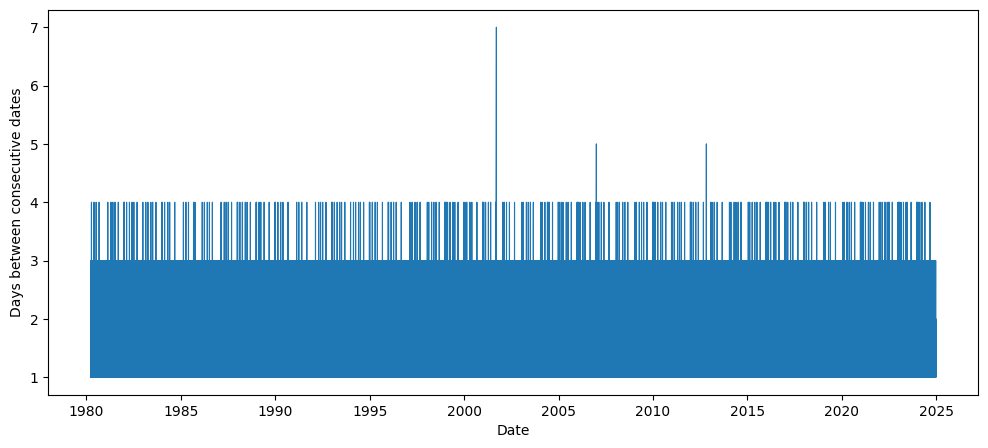

In [11]:
#Checking if there are any missing trading dates
df['Date']=pd.to_datetime(df['Date'])
df=df.sort_values('Date')
date_difference=df['Date'].diff().dt.days

plt.figure(figsize=(12,5))
plt.plot(df['Date'],date_difference,linewidth=0.8)
plt.xlabel('Date')
plt.ylabel('Days between consecutive dates')

In [12]:
df.isnull().sum()

,0
Date,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [13]:
df.dtypes.value_counts()

,count
float64,5
datetime64[ns],1
int64,1


In [14]:
#Checking if there are duplicate dates
df.duplicated(subset='Date').sum()

np.int64(0)

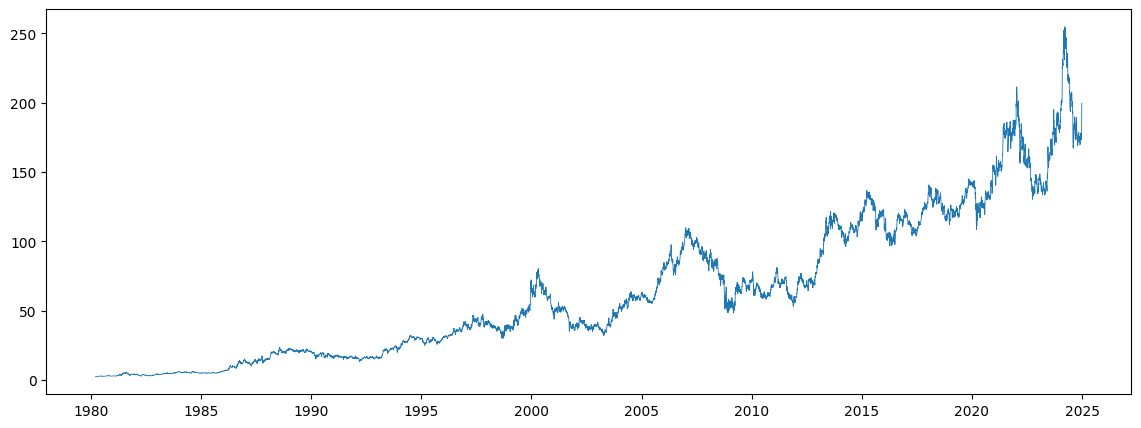

In [15]:
# Historical Adj close price analysis
plt.figure(figsize=(14,5))
plt.plot(df['Date'],df['Adj Close'],linewidth=0.6)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [17]:
df['Days']=(df['Date']-df['Date'].min()).dt.days

In [18]:
df.drop(['Date'],axis=1,inplace=True)
col=df.pop(df.columns[6])
df.insert(0,col.name,col)
df.head()


,Days,Adj Close,Close,High,Low,Open,Volume
0,0,2.296798,3.291227,3.344743,3.291227,0.000000,41109
1,1,2.306134,3.304606,3.358122,3.304606,0.000000,9343
2,2,2.306134,3.304606,3.304606,3.304606,3.304606,0
3,3,2.306134,3.304606,3.358122,3.304606,0.000000,10277
4,4,2.362154,3.384880,3.438396,3.384880,0.000000,8409


##Task 1: Predicting Volume on each days data

In [19]:
X=df.iloc[:,0:6]
Y=df.iloc[:,6]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
scaler_x=StandardScaler()
scaler_y=StandardScaler()
X_train=scaler_x.fit_transform(X_train)
X_test=scaler_x.transform(X_test)
Y_train=scaler_y.fit_transform(Y_train.values.reshape(-1,1))
Y_test=scaler_y.transform(Y_test.values.reshape(-1,1))

In [20]:
df.dtypes

,0
Days,int64
Adj Close,float64
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


In [21]:
svr=SVR(kernel='rbf',C=1000,gamma=0.5,epsilon=0.1)
svr.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR(C=1000, gamma=0.5)

In [22]:
y_pred=svr.predict(X_test)

In [23]:
mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)
print(f"mse={mse}")
print(f"mae={mae}")

mse=0.288747835376251
mae=0.19788125687957228


In [24]:
from sklearn.metrics import r2_score
r2=r2_score(Y_test,y_pred)
print(f"r squared: {r2}")

r squared: 0.5987558284908934


## Task 2: Predicting volume on the average of previous 5 days' Volume data

In [25]:
df=pd.read_csv("/content/data/Toyota_Data.csv")
df['Date']=pd.to_datetime(df['Date'])
df=df.sort_values('Date').reset_index(drop=True)

#Lagged/past features
df['Volume_lag1']=df['Volume'].shift(1)
df['Volume_avg5_past']=df['Volume'].shift(1).rolling(window=5).mean()
df['Close_lag1'] = df['Close'].shift(1)
df['HighLow_range_lag1']=(df['High'] - df['Low']).shift(1)
df['OpenClose_gap_lag1']=(df['Close'] - df['Open']).shift(1)

#Target: tomorrow's volume (shift-1=future)
df['Target']=df['Volume'].shift(-1)

df=df.dropna().reset_index(drop=True)

feature_cols=['Volume_lag1', 'Volume_avg5_past', 'Close_lag1',
                 'HighLow_range_lag1', 'OpenClose_gap_lag1']
X=df[feature_cols]
Y=df['Target']

In [26]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
scaler_x=StandardScaler()
scaler_y=StandardScaler()
X_train=scaler_x.fit_transform(X_train)
X_test=scaler_x.transform(X_test)
Y_train=scaler_y.fit_transform(Y_train.values.reshape(-1,1))
Y_test=scaler_y.transform(Y_test.values.reshape(-1,1))

In [29]:
import xgboost as xgb
xgbr=xgb.XGBRegressor()
xgbr.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [30]:
y_pred=xgbr.predict(X_test)

In [31]:
mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)
print(f"mse={mse}")
print(f"mae={mae}")

mse=1.1320285241063992
mae=0.24381044571761398


In [32]:
from sklearn.metrics import r2_score
r2=r2_score(Y_test,y_pred)
print(f"r squared: {r2}")

r squared: 0.36068263412510415


## Task 3: Next day Low price(Best price to buy at) prediction without same day leakage.

In [99]:
df=pd.read_csv("/content/data/Toyota_Data.csv")
df['Date']=pd.to_datetime(df['Date'])
df=df.sort_values('Date').reset_index(drop=True)

In [100]:
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,1980-03-17,2.296798,3.291227,3.344743,3.291227,0.000000,41109
1,1980-03-18,2.306134,3.304606,3.358122,3.304606,0.000000,9343
2,1980-03-19,2.306134,3.304606,3.304606,3.304606,3.304606,0
3,1980-03-20,2.306134,3.304606,3.358122,3.304606,0.000000,10277
4,1980-03-21,2.362154,3.384880,3.438396,3.384880,0.000000,8409


In [102]:
#Feature Engineering
df['Return 1d']=df['Close'].pct_change()
df['High-Low range']=df['High']-df['Low']
df['Open-Close gap']=df['Open']-df['Close']

#t=tommorow
df['Close_t']=df['Close']
df['Open_t']=df['Open']
df['High_t']=df['High']
df['Low_t']=df['Low']
df['Volume_t']=df['Volume']
df['Adj Close_t']=df['Adj Close']
df['Return_t']=df['Return 1d']
df['Range_t']=df['High-Low range']
df['Gap_t']=df['Open-Close gap']

#Rolling stats using previous 5 days data
df['Close avg']=df['Close'].shift(1).rolling(5).mean()
df['Volume avg']=df['Volume'].shift(1).rolling(5).mean()
df['Volatility past']=df['Return 1d'].shift(1).rolling(5).std()
df['Day']=df['Date'].dt.dayofweek
df['Month']=df['Date'].dt.month

#Target=Tommorow's low price
df['Target low change']=df['Low'].shift(-1)-df['Close']

features=['Close_t','Open_t','High_t','Low_t','Volume_t','Adj Close_t','Return_t','Range_t','Gap_t','Close avg','Volume avg','Volatility past','Day','Month']
df_model=df.dropna(subset=features+['Target low change']).reset_index(drop=True)


X=df_model[features]
Y=df_model['Target low change']
dates=df_model['Date']
df_model.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Return 1d,High-Low range,Open-Close gap,...,Adj Close_t,Return_t,Range_t,Gap_t,Close avg,Volume avg,Volatility past,Day,Month,Target low change
0,1980-03-25,2.352816,3.371501,3.425017,3.371501,0.0,27095,-0.007874,0.053516,-3.371501,...,2.352816,-0.007874,0.053516,-3.371501,3.339391,6166.4,0.010167,1,3,0.000000
1,1980-03-26,2.352816,3.371501,3.425017,3.371501,0.0,1869,0.000000,0.053516,-3.371501,...,2.352816,0.000000,0.053516,-3.371501,3.352770,9716.8,0.012090,2,3,-0.040137
2,1980-03-27,2.324807,3.331364,3.384880,3.331364,0.0,14015,-0.011905,0.053516,-3.331364,...,2.324807,-0.011905,0.053516,-3.331364,3.366149,10090.6,0.012090,3,3,-0.013379
3,1980-03-28,2.315470,3.317985,3.371501,3.317985,0.0,36438,-0.004016,0.053516,-3.317985,...,2.315470,-0.004016,0.053516,-3.317985,3.371501,10838.2,0.014099,4,3,0.000000
4,1980-03-31,2.315470,3.317985,3.371501,3.317985,0.0,1869,0.000000,0.053516,-3.317985,...,2.315470,0.000000,0.053516,-3.317985,3.358122,16444.0,0.006260,0,3,-0.053516


In [106]:
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
Y_train, Y_test = Y.iloc[:split_idx], Y.iloc[split_idx:]

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_x.fit_transform(X_train)
X_test_s = scaler_x.transform(X_test)
Y_train_s = scaler_y.fit_transform(Y_train.values.reshape(-1, 1)).ravel()
Y_test_s = scaler_y.transform(Y_test.values.reshape(-1, 1)).ravel()

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} metrics")
    print(f"mae={mae}")
    print(f"mse={mse}")
    print(f"r2={r2}")
    return {"name": name, "mae": mae, "mse": mse, "r2": r2}

In [107]:
svr = SVR(kernel='rbf', C=1, gamma=0.001, epsilon=0.1)
svr.fit(X_train_s, Y_train_s)
svr_pred = scaler_y.inverse_transform(svr.predict(X_test_s).reshape(-1, 1)).ravel()
evaluate("SVR (rbf, C=1, gamma=0.001)", Y_test, svr_pred)

# check overfitting
svr_train_pred = scaler_y.inverse_transform(svr.predict(X_train_s).reshape(-1, 1)).ravel()
train_r2 = r2_score(Y_train, svr_train_pred)
test_r2 = r2_score(Y_test, svr_pred)
print(f"SVR train R2={train_r2:.4f}  test R2={test_r2:.4f}  gap={train_r2 - test_r2:.4f}\n")


SVR (rbf, C=1, gamma=0.001) metrics
mae=1.4082900217657683
mse=4.0599703720534075
r2=0.027551668989788558
SVR train R2=0.0957  test R2=0.0276  gap=0.0681



In [108]:
#grid search for bettet results
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.0001, 0.001, 0.01, 'scale'],
    'epsilon': [0.01, 0.1, 0.5]
}
grid = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train_s, Y_train_s)

print("Best params:", grid.best_params_)
print("Best CV R2 (on scaled training folds):", grid.best_score_)

best_svr = grid.best_estimator_
best_pred = scaler_y.inverse_transform(best_svr.predict(X_test_s).reshape(-1, 1)).ravel()
evaluate("SVR (grid-search tuned)", Y_test, best_pred)

best_train_pred = scaler_y.inverse_transform(best_svr.predict(X_train_s).reshape(-1, 1)).ravel()
tuned_train_r2 = r2_score(Y_train, best_train_pred)
tuned_test_r2 = r2_score(Y_test, best_pred)
print(f"Tuned SVR train R2={tuned_train_r2:.4f}  test R2={tuned_test_r2:.4f}  gap={tuned_train_r2 - tuned_test_r2:.4f}")

Best params: {'C': 10, 'epsilon': 0.01, 'gamma': 0.001}
Best CV R2 (on scaled training folds): 0.010971341124828523
SVR (grid-search tuned) metrics
mae=1.4061658072956846
mse=4.058601369786548
r2=0.027879573838237692
Tuned SVR train R2=0.1003  test R2=0.0279  gap=0.0724
